In [3]:
import pandas as pd

df = pd.read_parquet("../data/train_data_weather.parquet")

In [4]:
small_df = df[:200]
small_df.to_csv("../data/train_data_weather.csv")

In [ ]:
import pickle

with open("../simulator/timetable.pkl", "rb") as f:
    PLANNED_SEGMENT_TIMES = pickle.load(f)

PLANNED_SEGMENT_TIMES.update({
    # IC5 — fix all 4 asymmetric pairs
    ("TUE",  "BI",   "IC5"): 180,  # was 300
    ("LIG",  "TWN",  "IC5"): 120,  # was 60  ← YOU HAD THIS MISSING
    ("SBL",  "CORN", "IC5"): 120,  # was 180
    ("NE",   "SBL",  "IC5"): 120,  # was 120 ✓ already correct
    # R13 — fix all asymmetric pairs
    ("NV",   "LIG",  "R13"): 180,  # was 240
    ("NE",   "SBL",  "R13"): 180,  # was 240 ← YOU HAD THIS MISSING
    ("CORN", "SBL",  "R13"): 180,  # was 180 ✓ already correct
    # R16 — fix all asymmetric pairs
    ("LIG",  "TWN",  "R16"):  60,  # was 60  ✓ already correct
    ("NV",   "LIG",  "R16"): 180,  # was 240
    ("CORN", "SBL",  "R16"): 180,  # was 180 ✓ already correct
    })

PLANNED_SEGMENT_TIMES

(array([36.,  0., 34.,  0.,  0., 34.,  0.,  1.,  0.,  1.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

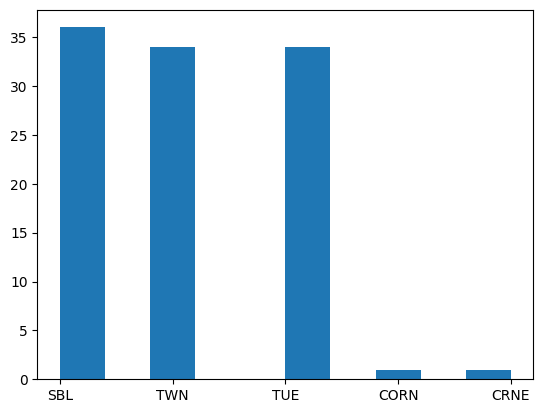

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("normal_weather.csv")

trains = df["train"].unique()
stations_list = df["station"].unique()

stations = []

for train in trains:
    df_train = df[(df["train"] == train)]
    df_delayed = df_train[(df_train["simulated_delay"]) > 50.0]
    
    if not df_delayed.empty:
        stat = df_delayed["station"]
        stat = list(stat)
        #print(f"Train {train}: First delay > 180s")
        #print(first_delay["station"])
        stations += (stat)
plt.hist(stations)
